In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("cleaned_financial_transactions_v2.csv")

df.head()

,transaction_id,transaction_date,customer_id,product_name,quantity,price,payment_method,transaction_status,total_amount,transaction_month,transaction_year,high_value_transaction
0,T0001,2024-02-08,C2205,Headphones,5.0,420.21,PayPal,Unknown,2101.05,2,2024,Yes
1,T0002,2020-10-02,C3156,Coffee,469.0,445.34,Credit Card,Pending,208865.41,10,2020,Yes
2,T0003,2023-01-13,C2919,Tablet,4.0,810.99,Credit Card,Completed,3243.97,1,2023,Yes
3,T0004,2023-01-13,C3009,Tab,7.0,868.61,PayPal,Pending,6080.26,1,2023,Yes
4,T0005,2023-01-13,C3488,Coffee Machine,10.0,763.12,PayPal,Completed,7631.22,1,2023,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99006 entries, 0 to 99005
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          94040 non-null  str    
 1   transaction_date        99006 non-null  str    
 2   customer_id             99006 non-null  str    
 3   product_name            99006 non-null  str    
 4   quantity                99006 non-null  float64
 5   price                   99006 non-null  float64
 6   payment_method          99006 non-null  str    
 7   transaction_status      99006 non-null  str    
 8   total_amount            99006 non-null  float64
 9   transaction_month       99006 non-null  int64  
 10  transaction_year        99006 non-null  int64  
 11  high_value_transaction  99006 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 9.1 MB


In [4]:
df.describe()

,quantity,price,total_amount,transaction_month,transaction_year
count,99006.000000,99006.000000,99006.000000,99006.000000,99006.000000
mean,178.473244,525.266603,93886.226647,1.694019,2022.882118
std,292.016768,223.638104,171968.630004,2.203199,0.602096
min,1.000000,50.030000,50.190000,1.000000,2020.000000
25%,4.000000,407.042500,1867.045000,1.000000,2023.000000
50%,8.000000,525.380000,4203.030000,1.000000,2023.000000
75%,292.000000,643.732500,115058.060000,1.000000,2023.000000
max,1000.000000,999.990000,994118.210000,12.000000,2025.000000


In [5]:
df.isnull().sum()

transaction_id            4966
transaction_date             0
customer_id                  0
product_name                 0
quantity                     0
price                        0
payment_method               0
transaction_status           0
total_amount                 0
transaction_month            0
transaction_year             0
high_value_transaction       0
dtype: int64

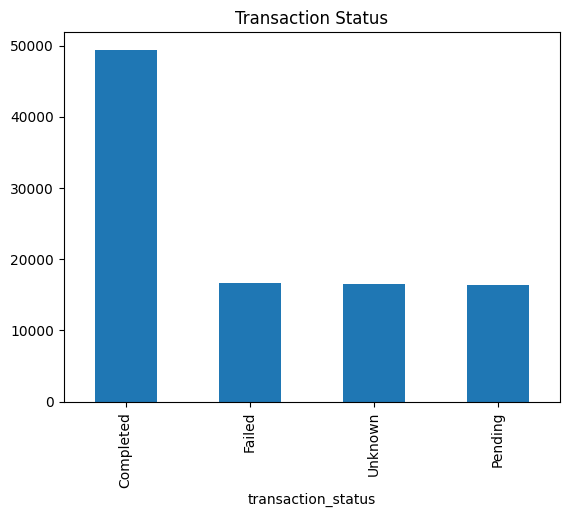

In [6]:
df['transaction_status'].value_counts().plot(kind='bar')
plt.title("Transaction Status")
plt.show()

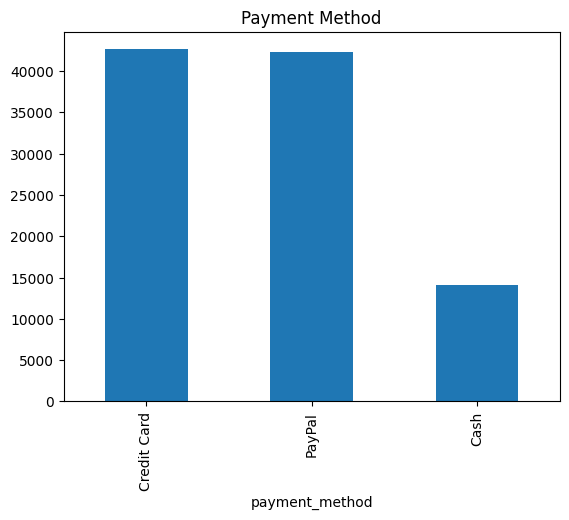

In [7]:
df['payment_method'].value_counts().plot(kind='bar')
plt.title("Payment Method")
plt.show()

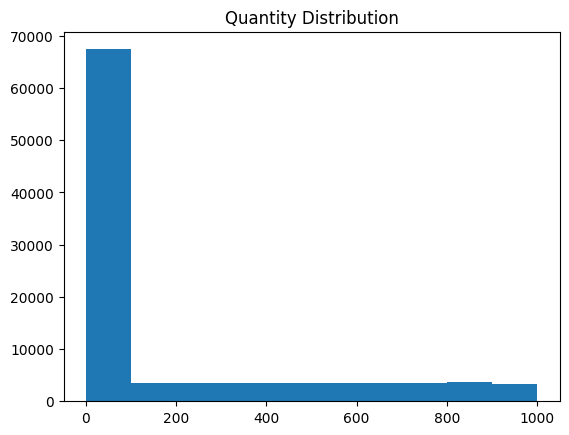

In [8]:
plt.hist(df['quantity'])
plt.title("Quantity Distribution")
plt.show()

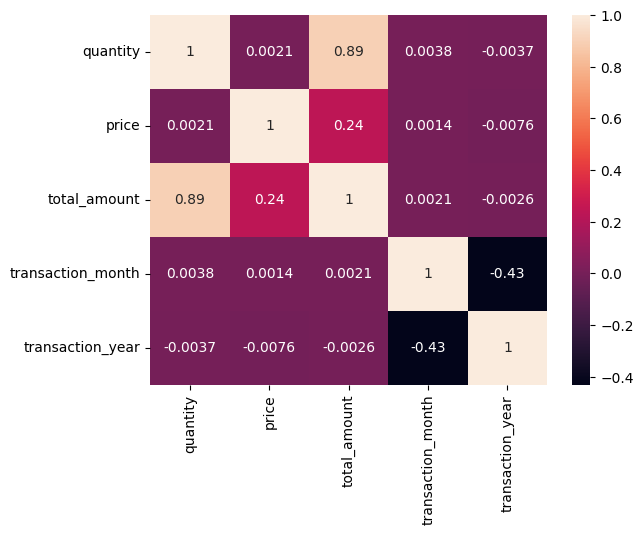

In [9]:
numeric = df.select_dtypes(include='number')

sns.heatmap(
    numeric.corr(),
    annot=True
)

plt.show()

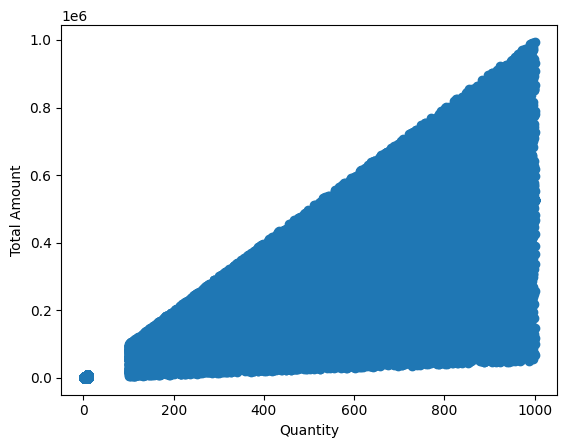

In [10]:
plt.scatter(
    df['quantity'],
    df['total_amount']
)

plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

In [14]:
import pandas as pd
import sqlite3

df = pd.read_csv("cleaned_financial_transactions_v2.csv")

conn = sqlite3.connect(':memory:')

df.to_sql('cafe_sales', conn, index=False, if_exists='replace')

query = "PRAGMA table_info(cafe_sales);"
print(pd.read_sql_query(query, conn))

    cid                    name     type  notnull dflt_value  pk
0     0          transaction_id     TEXT        0       None   0
1     1        transaction_date     TEXT        0       None   0
2     2             customer_id     TEXT        0       None   0
3     3            product_name     TEXT        0       None   0
4     4                quantity     REAL        0       None   0
5     5                   price     REAL        0       None   0
6     6          payment_method     TEXT        0       None   0
7     7      transaction_status     TEXT        0       None   0
8     8            total_amount     REAL        0       None   0
9     9       transaction_month  INTEGER        0       None   0
10   10        transaction_year  INTEGER        0       None   0
11   11  high_value_transaction     TEXT        0       None   0


In [17]:
query = """
SELECT product_name,
       ROUND(SUM(total_amount), 2) AS revenue
FROM cafe_sales
GROUP BY product_name
ORDER BY revenue DESC
LIMIT 5;
"""

result = pd.read_sql_query(query, conn)
print(result)

     product_name       revenue
0          Tablet  1.725572e+09
1          Laptop  1.688761e+09
2      Headphones  1.677952e+09
3      Smartphone  1.677593e+09
4  Coffee Machine  1.656263e+09


In [19]:
query = """
SELECT payment_method,
       ROUND(SUM(total_amount), 2) AS revenue
FROM cafe_sales
GROUP BY payment_method
ORDER BY revenue DESC;
"""

pd.read_sql_query(query, conn)

,payment_method,revenue
0,Credit Card,4.016840e+09
1,PayPal,3.976202e+09
2,Cash,1.302257e+09


In [20]:
query = """
SELECT transaction_status,
       COUNT(*) AS total_transactions
FROM cafe_sales
GROUP BY transaction_status;
"""

pd.read_sql_query(query, conn)

,transaction_status,total_transactions
0,Completed,49413
1,Failed,16629
2,Pending,16443
3,Unknown,16521


In [21]:
query = """
SELECT product_name,
       SUM(quantity) AS units_sold
FROM cafe_sales
GROUP BY product_name
ORDER BY units_sold DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,product_name,units_sold
0,Tablet,3266410.0
1,Headphones,3213283.0
2,Smartphone,3211360.0
3,Laptop,3196421.0
4,Coffee Machine,3145804.0
5,Lapto,67669.0
6,La,67654.0
7,Tabl,67650.0
8,Ta,67407.0
9,Lap,64327.0


In [22]:
query = """
SELECT high_value_transaction,
       COUNT(*) AS transaction_count
FROM cafe_sales
GROUP BY high_value_transaction;
"""

pd.read_sql_query(query, conn)

,high_value_transaction,transaction_count
0,No,12998
1,Yes,86008
